# **CHURN ANALYSIS - FIZRA MILANO L**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_column', None)

In [ ]:
folder_name = "/content/drive/My Drive/Colab Notebooks"

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import sys
sys.path.append(f'{folder_name}')

Mounted at /content/drive


In [ ]:
df = pd.read_csv(f'{folder_name}/Churn_Analysis.csv', sep=',', skipinitialspace=True, na_values="?" )
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


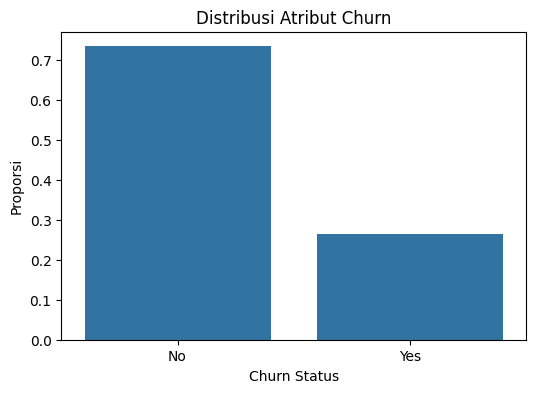

In [ ]:
churn_counts = df['Churn'].value_counts(normalize=True).reset_index()
churn_counts.columns = ['Churn', 'Proportion']

plt.figure(figsize=(6, 4))
sns.barplot(x='Churn', y='Proportion', data=churn_counts)
plt.title('Distribusi Atribut Churn')
plt.xlabel('Churn Status')
plt.ylabel('Proporsi')
plt.xticks([0, 1])
plt.show()

# **Numerical Data**

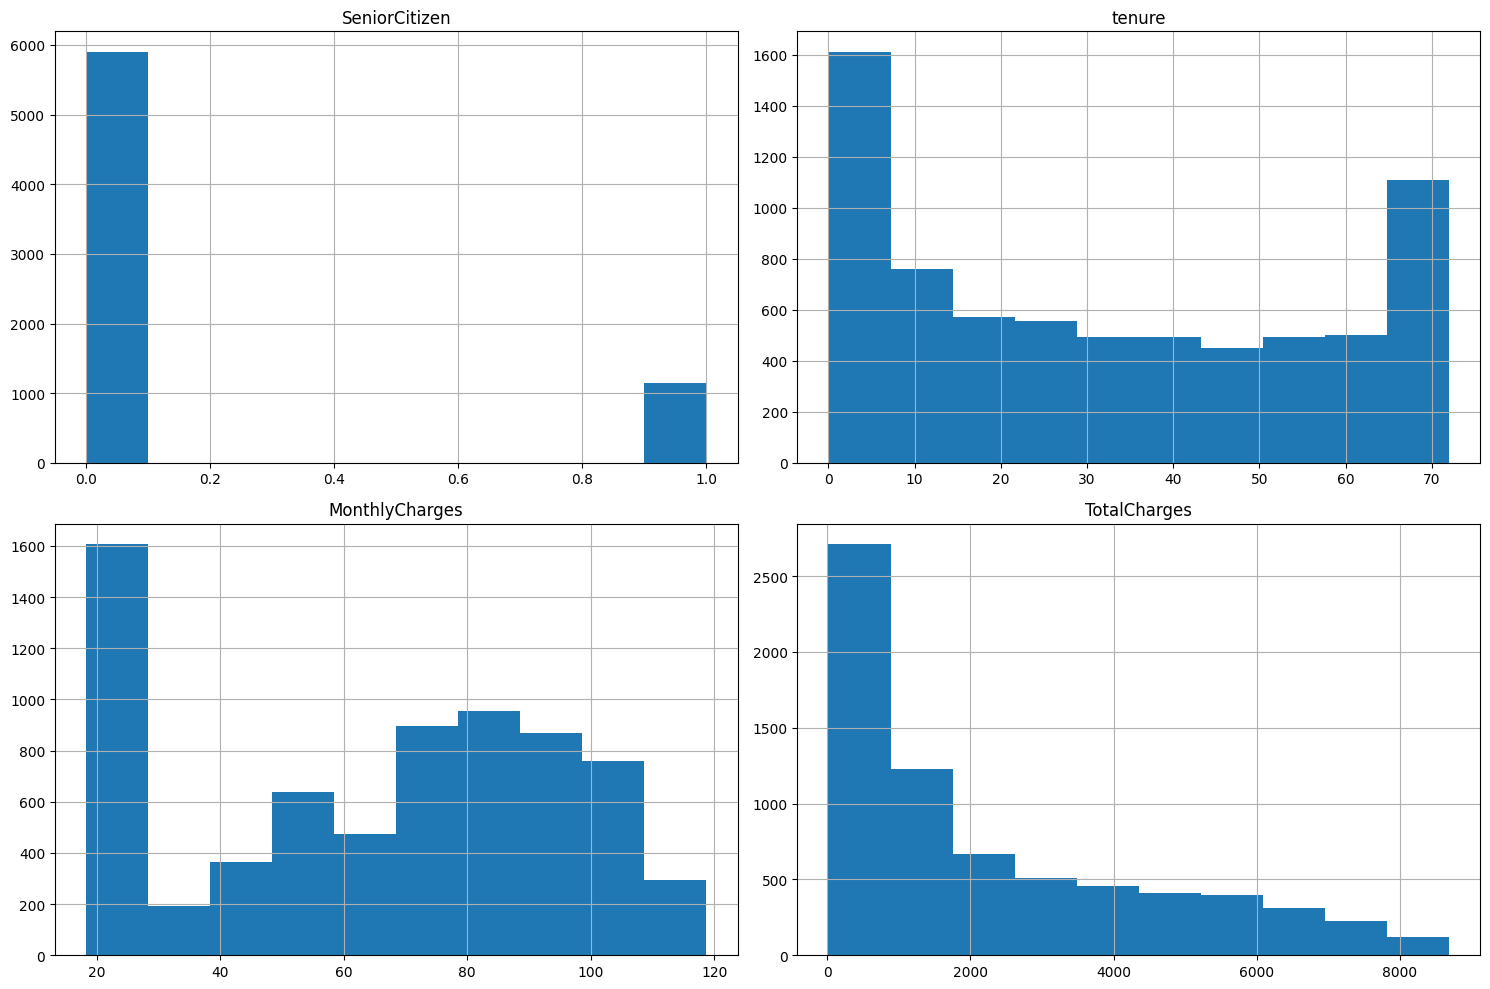

In [ ]:
numeric_features = df.select_dtypes(include=[np.number]).columns
df[numeric_features].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

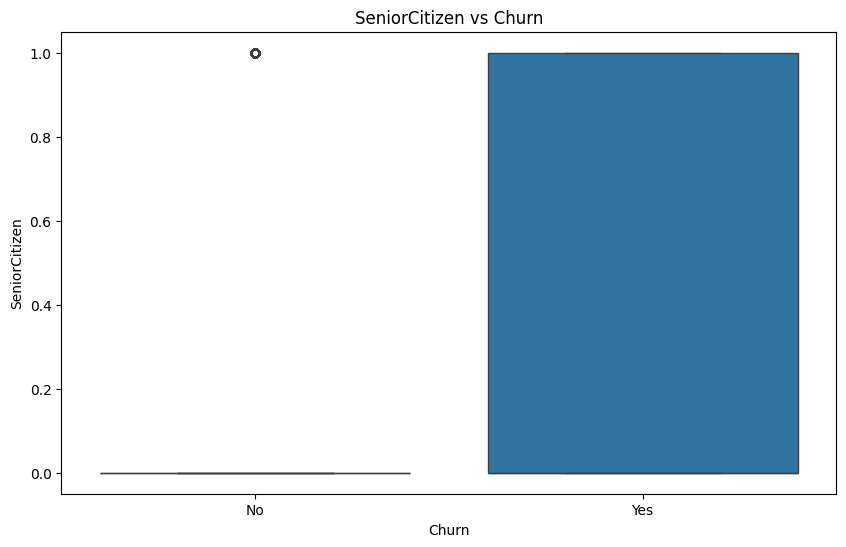

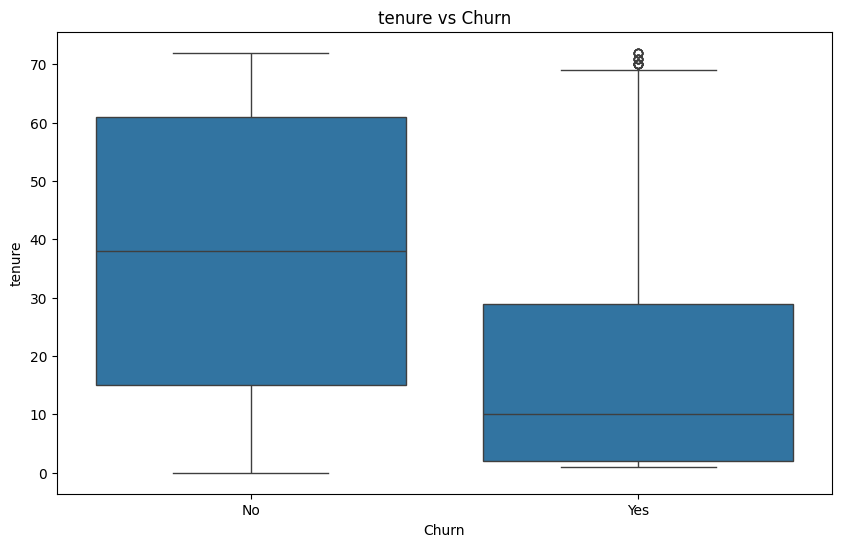

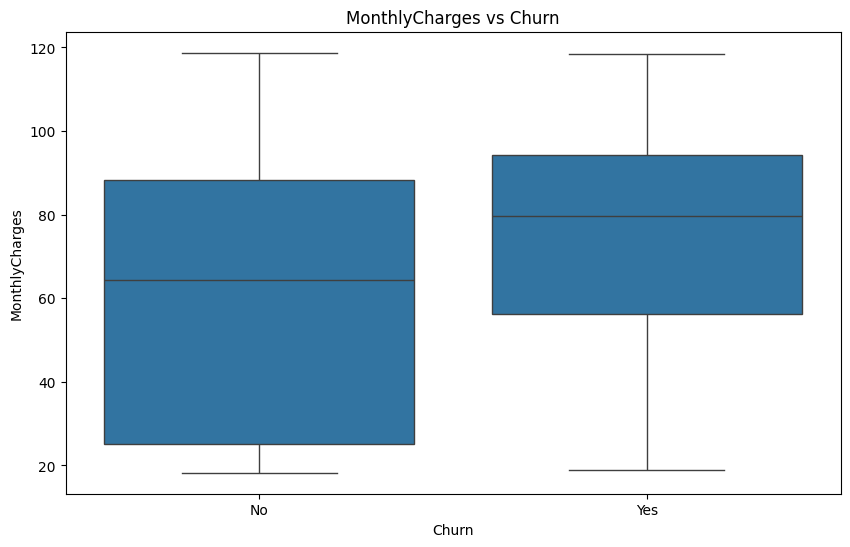

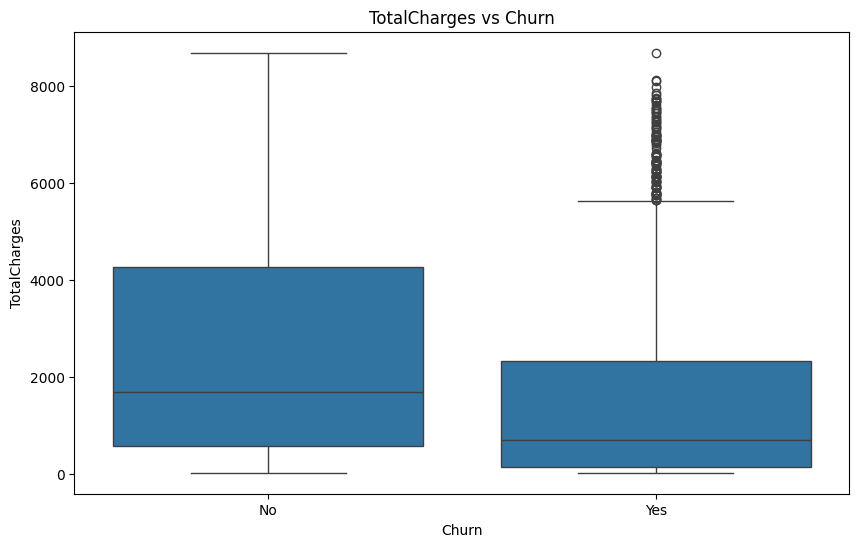

In [ ]:
numeric_features = df.select_dtypes(include=[np.number]).columns

for feature in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Churn', y=feature, data=df)
    plt.title(f'{feature} vs Churn')
    plt.show()

# **Categorical Data**

In [ ]:
df = df.drop(['customerID'], axis=1)

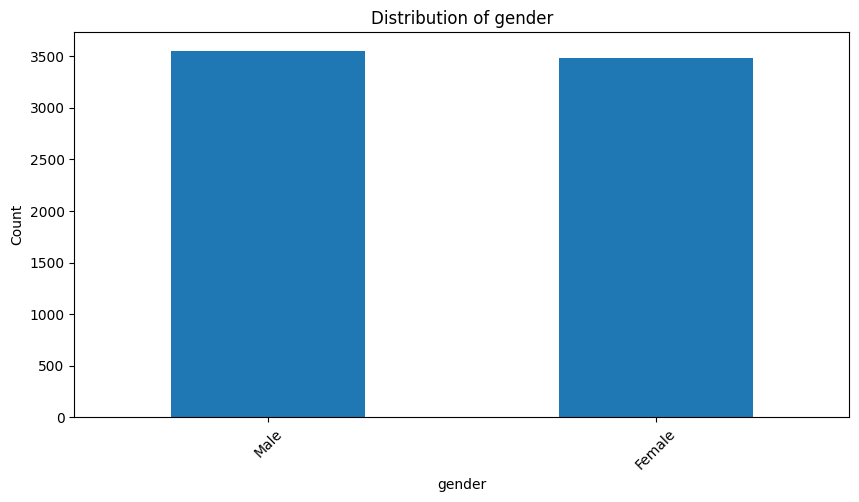

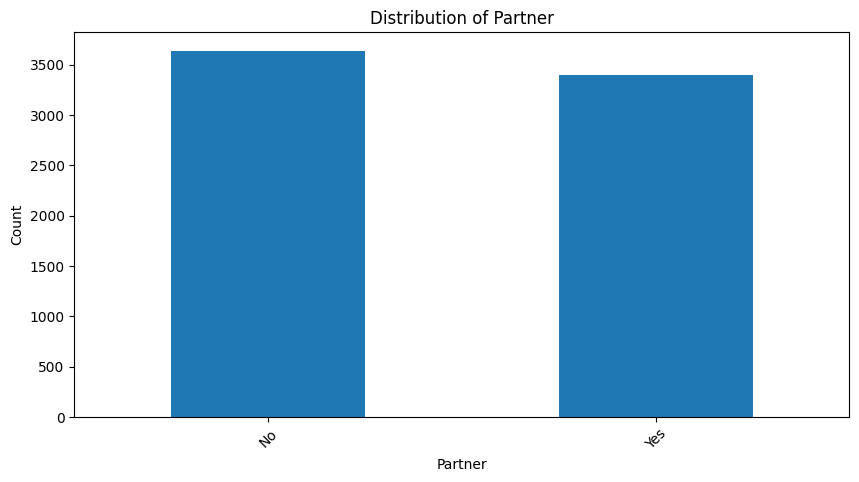

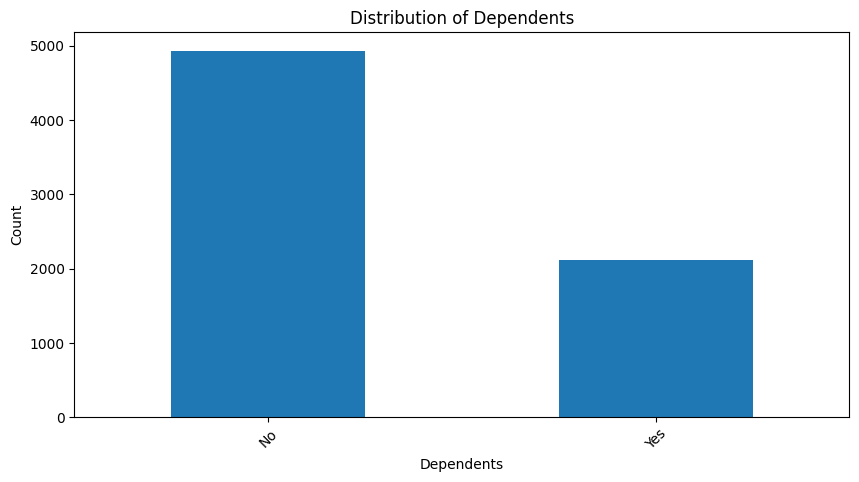

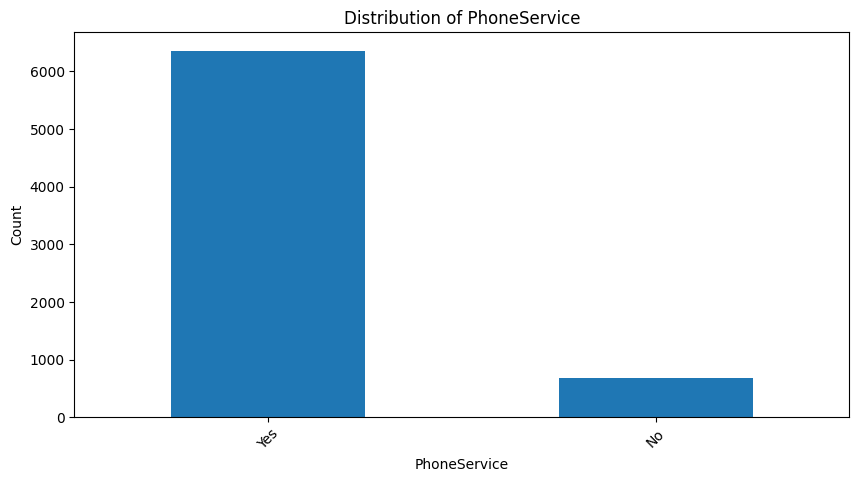

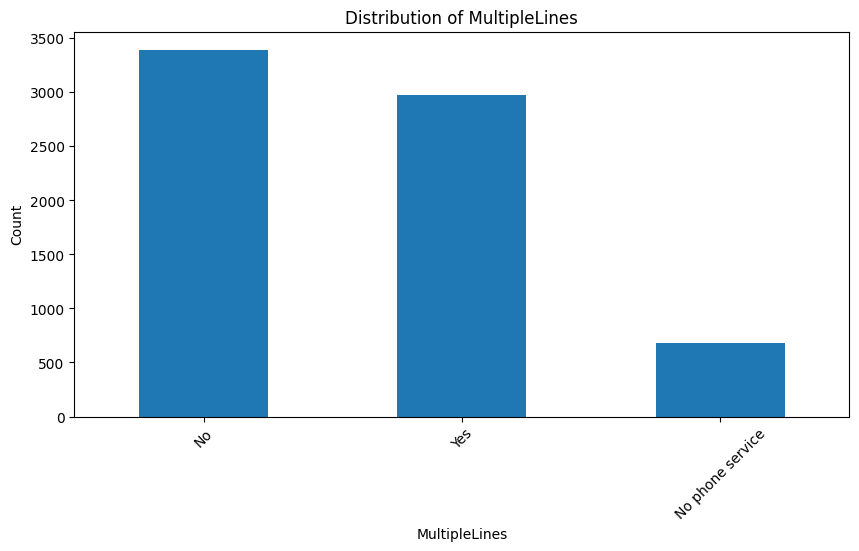

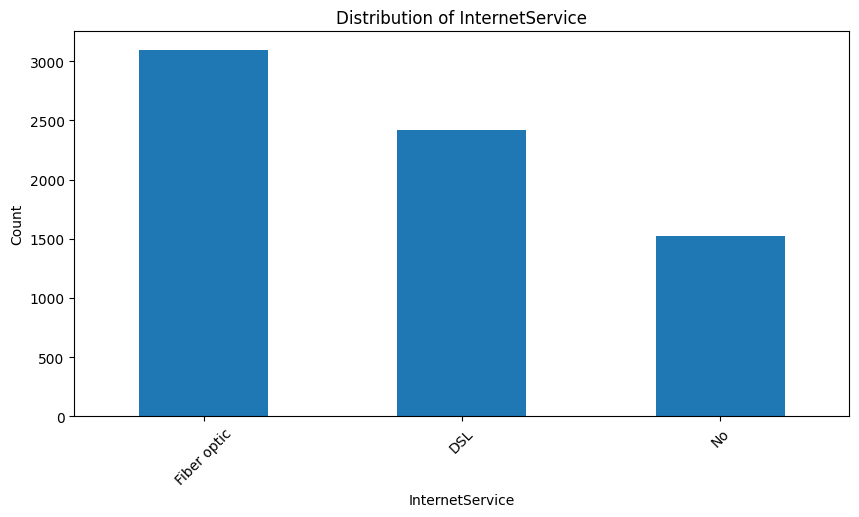

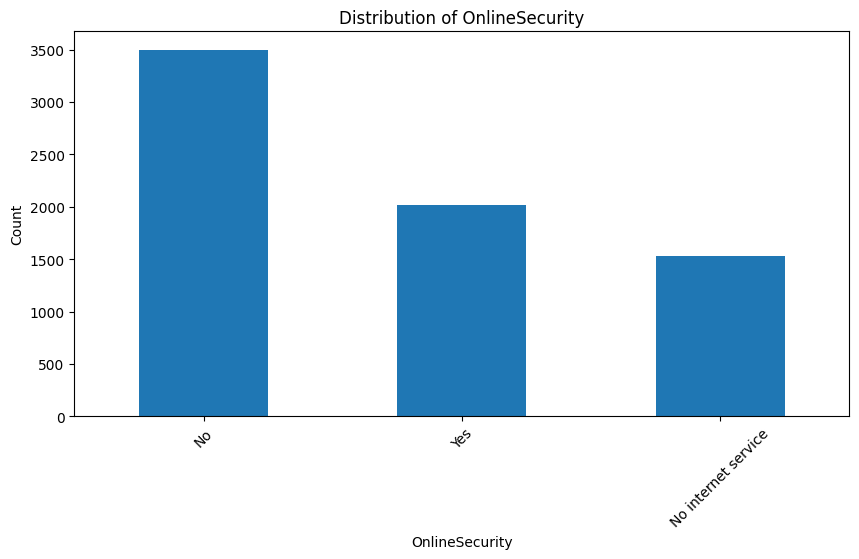

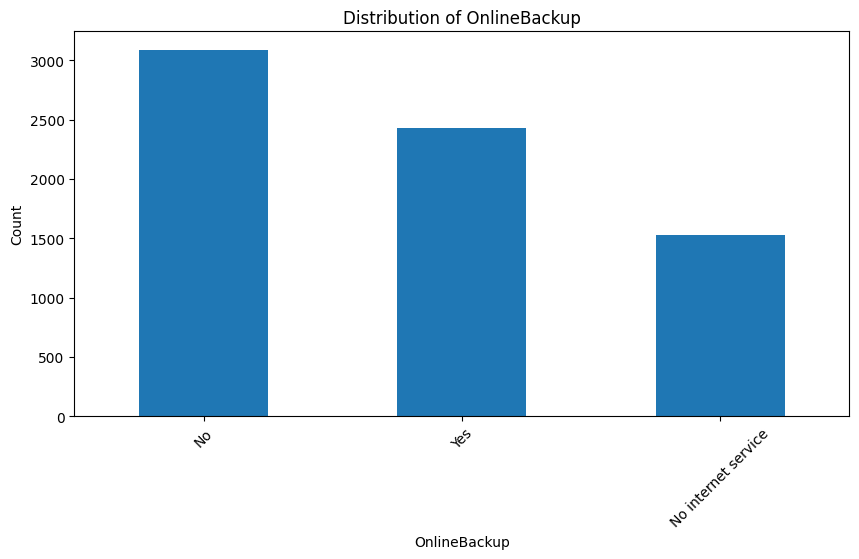

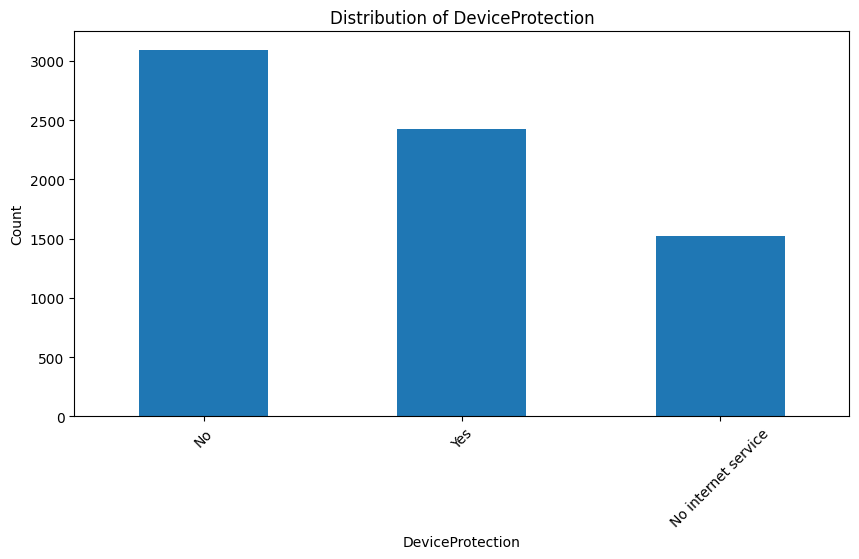

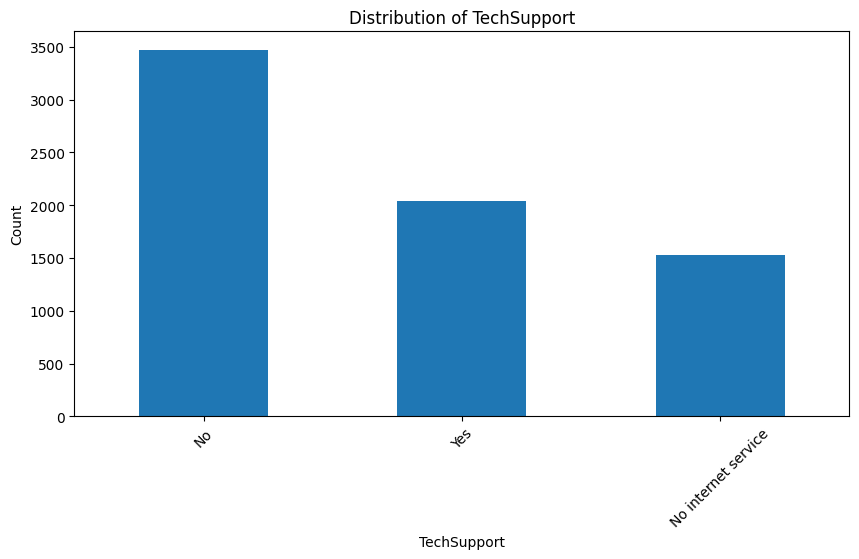

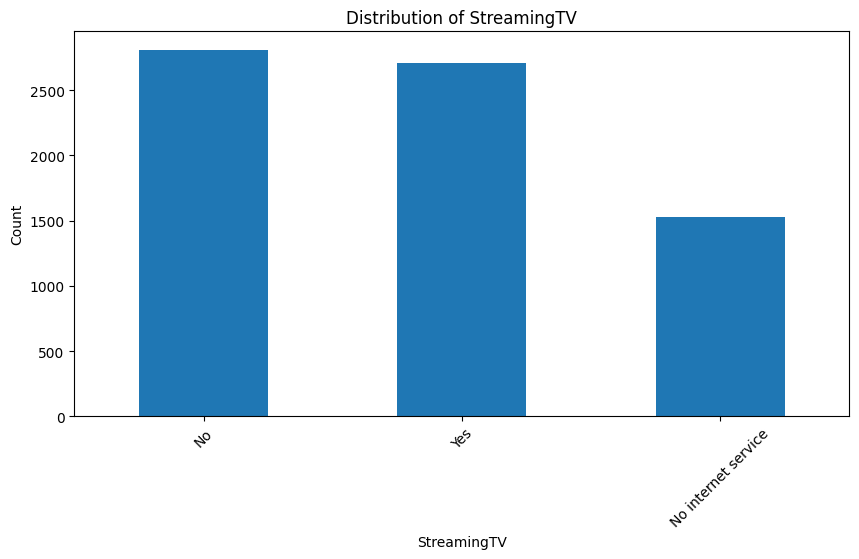

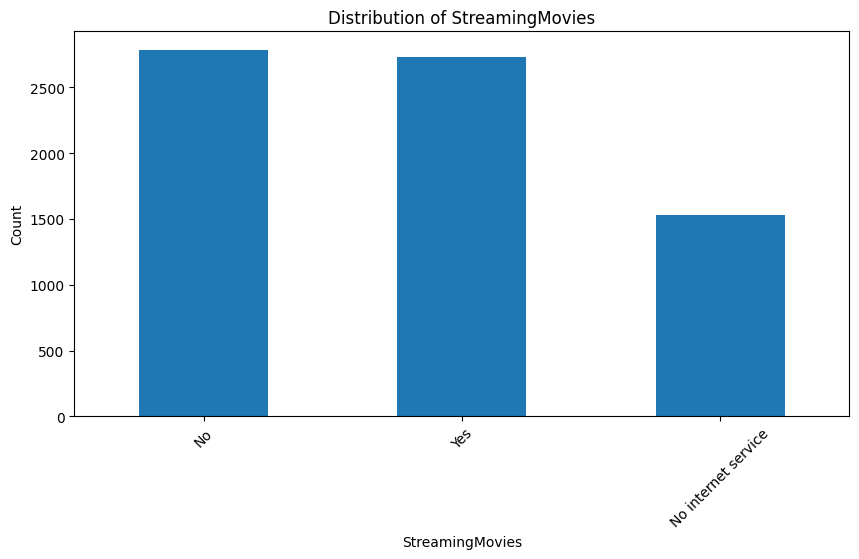

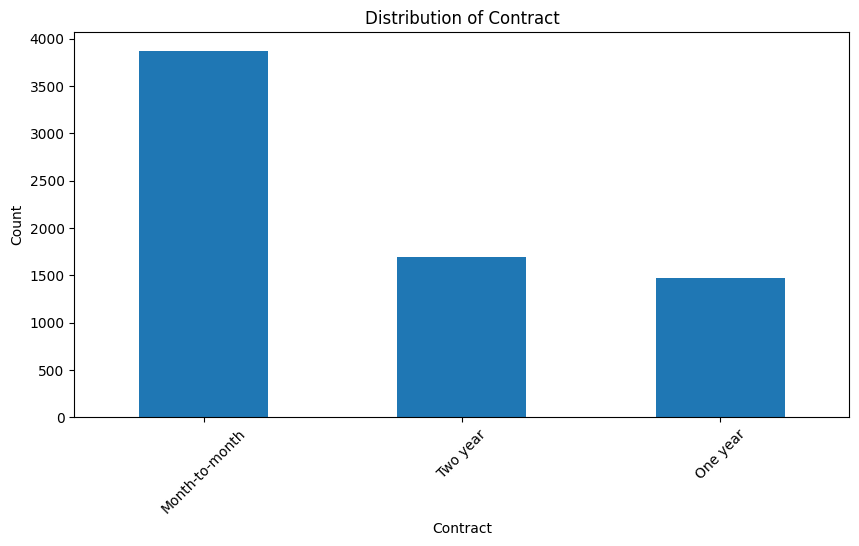

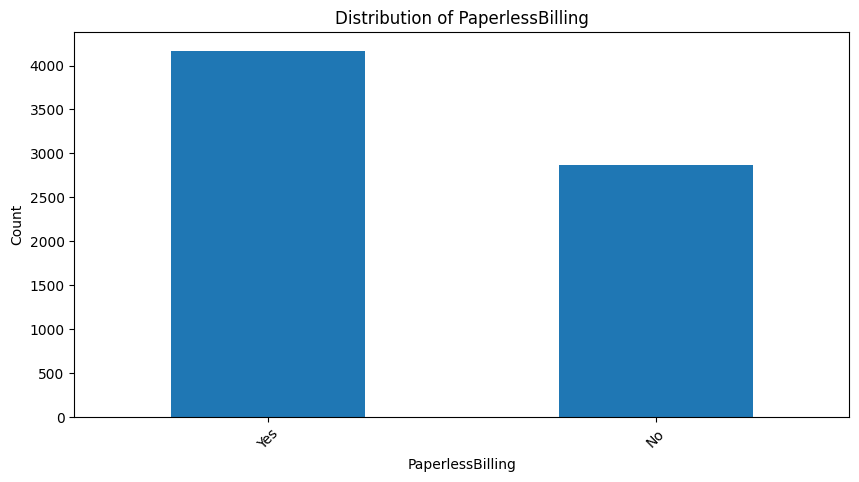

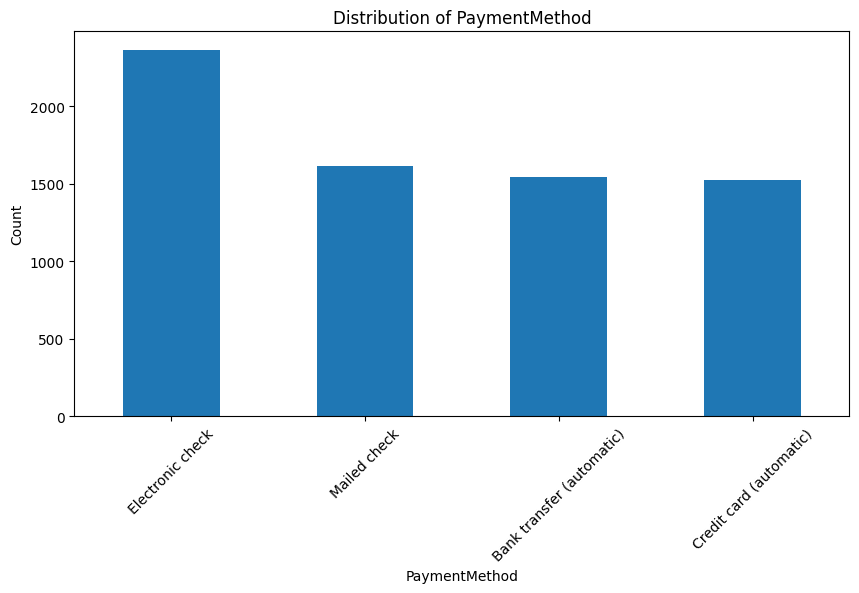

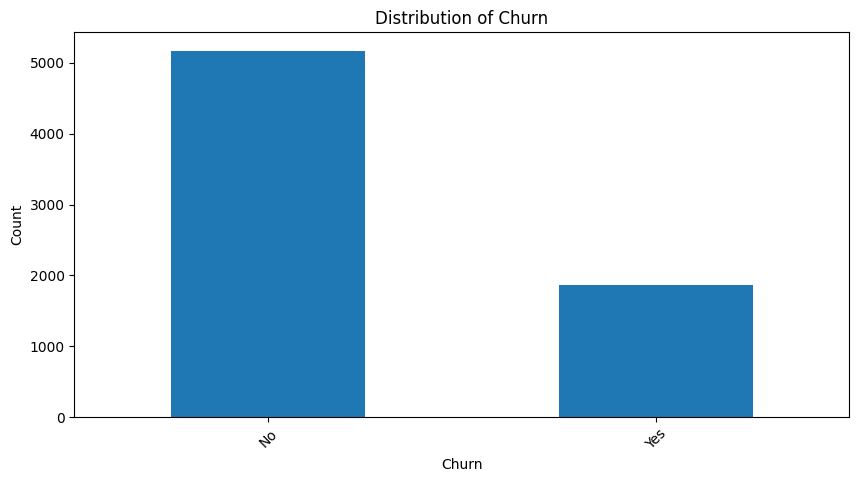

In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns
for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    df[feature].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {feature}')
    plt.ylabel('Count')
    plt.xlabel(feature)
    plt.xticks(rotation=45)
    plt.show()

<Figure size 1800x600 with 0 Axes>

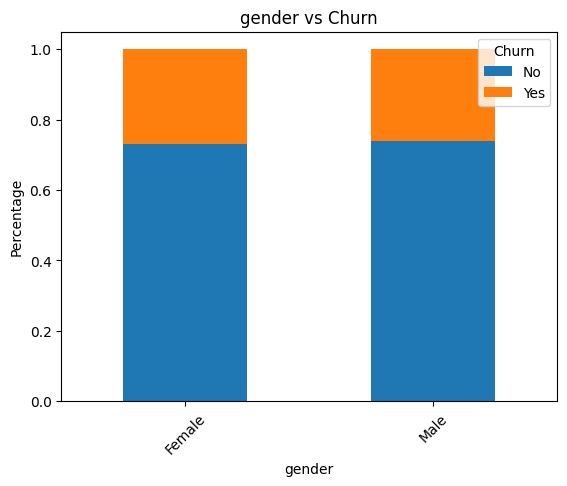

<Figure size 1800x600 with 0 Axes>

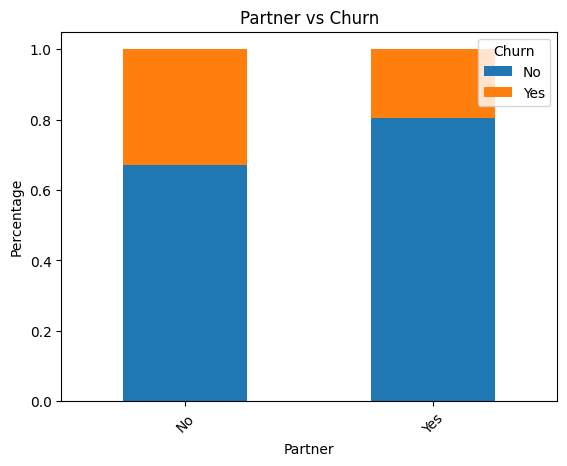

<Figure size 1800x600 with 0 Axes>

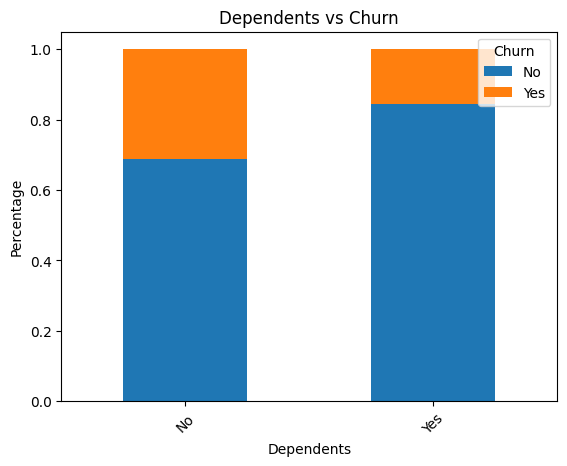

<Figure size 1800x600 with 0 Axes>

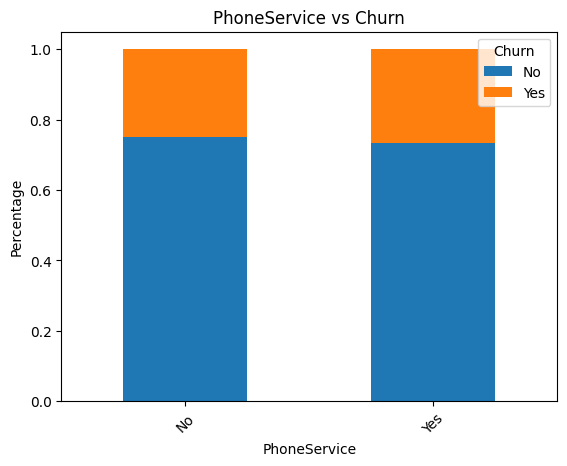

<Figure size 1800x600 with 0 Axes>

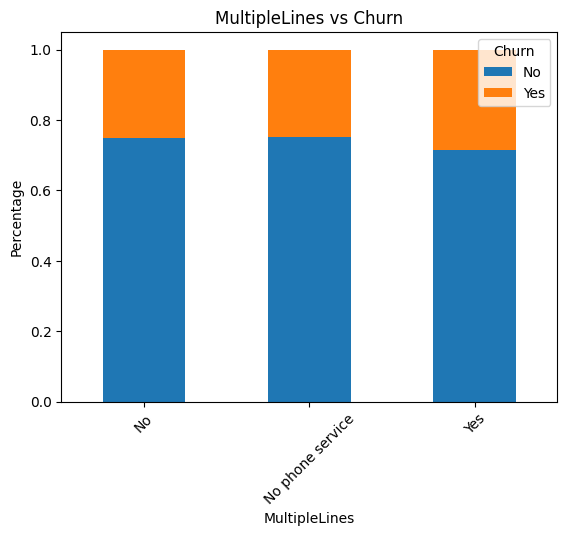

<Figure size 1800x600 with 0 Axes>

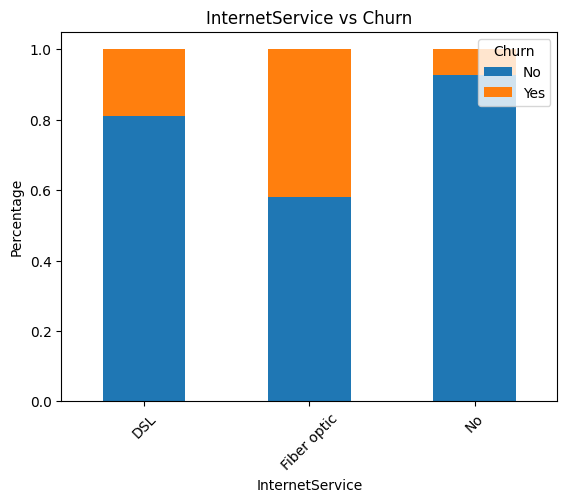

<Figure size 1800x600 with 0 Axes>

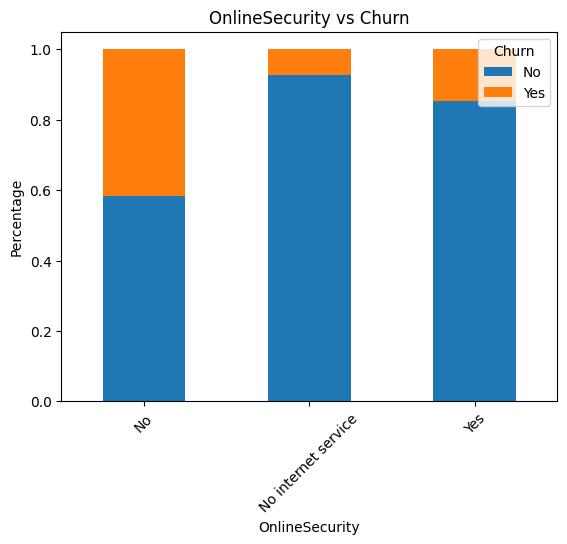

<Figure size 1800x600 with 0 Axes>

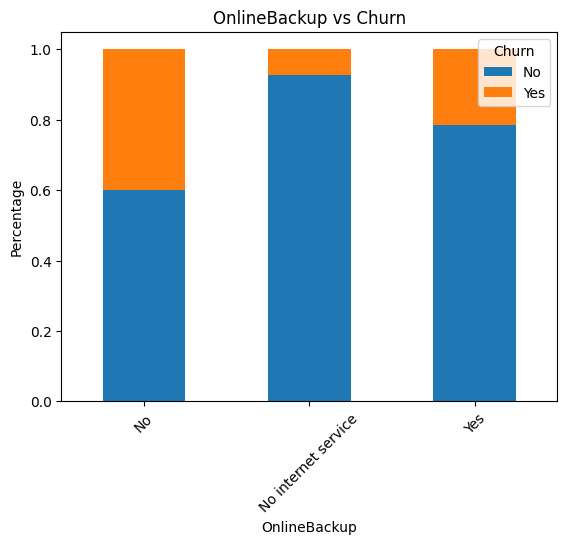

<Figure size 1800x600 with 0 Axes>

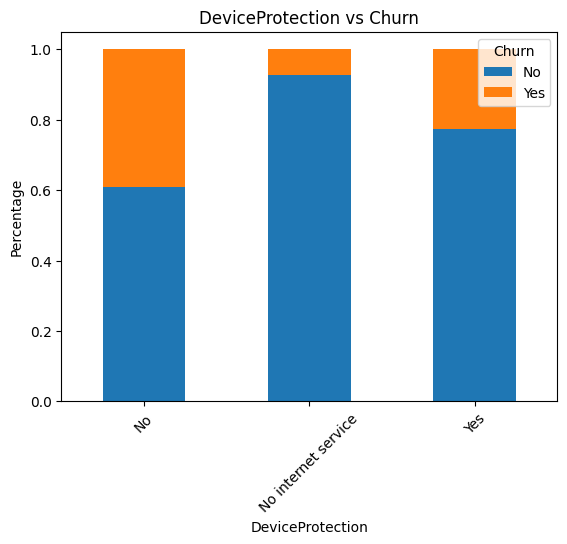

<Figure size 1800x600 with 0 Axes>

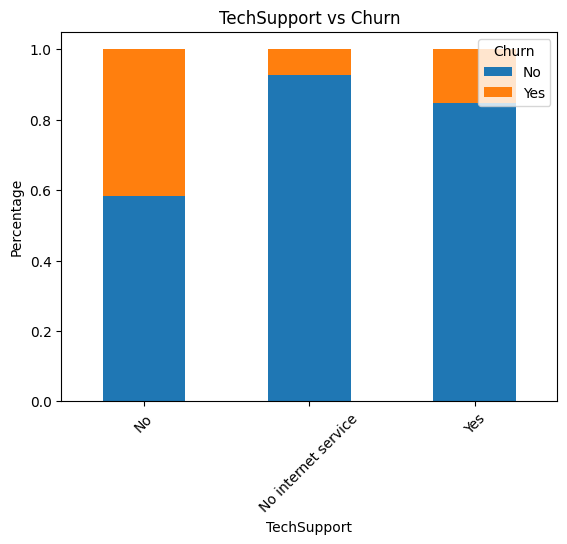

<Figure size 1800x600 with 0 Axes>

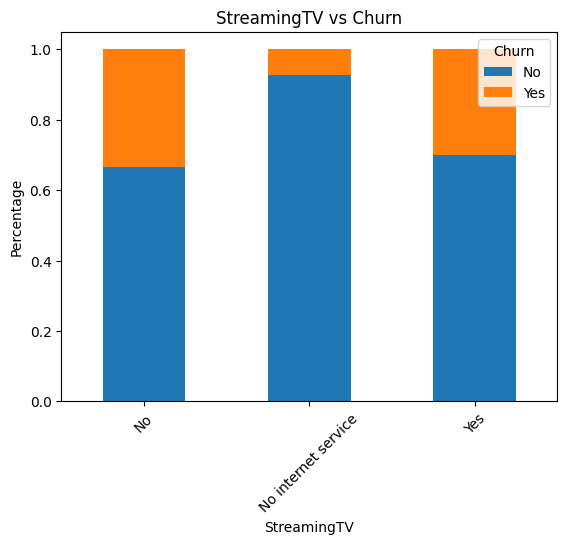

<Figure size 1800x600 with 0 Axes>

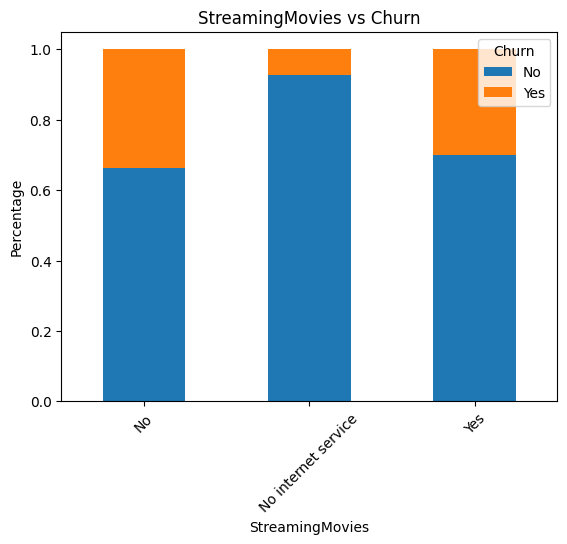

<Figure size 1800x600 with 0 Axes>

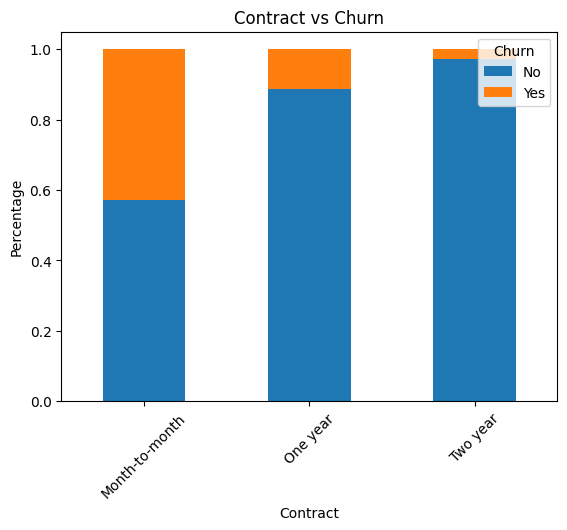

<Figure size 1800x600 with 0 Axes>

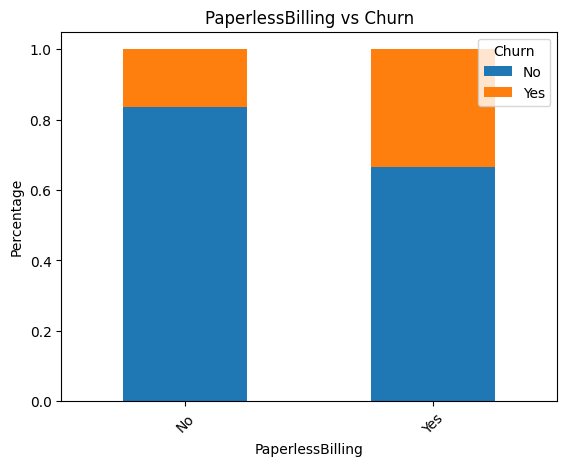

<Figure size 1800x600 with 0 Axes>

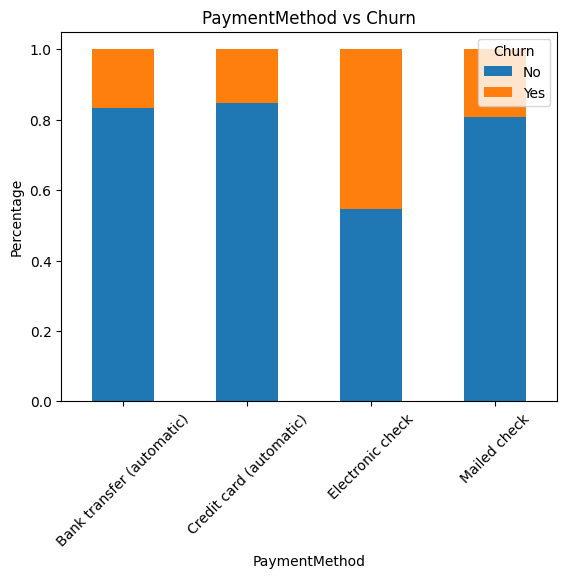

In [ ]:
for feature in categorical_features:
    if feature != 'Churn':
        plt.figure(figsize=(18, 6))
        df_temp = df.groupby([feature, 'Churn']).size().unstack()
        df_temp_perc = df_temp.div(df_temp.sum(axis=1), axis=0)
        df_temp_perc.plot(kind='bar', stacked=True)
        plt.title(f'{feature} vs Churn')
        plt.xlabel(feature)
        plt.ylabel('Percentage')
        plt.legend(title='Churn', loc='upper right')
        plt.xticks(rotation=45)
        plt.show()

# **KORELASI**

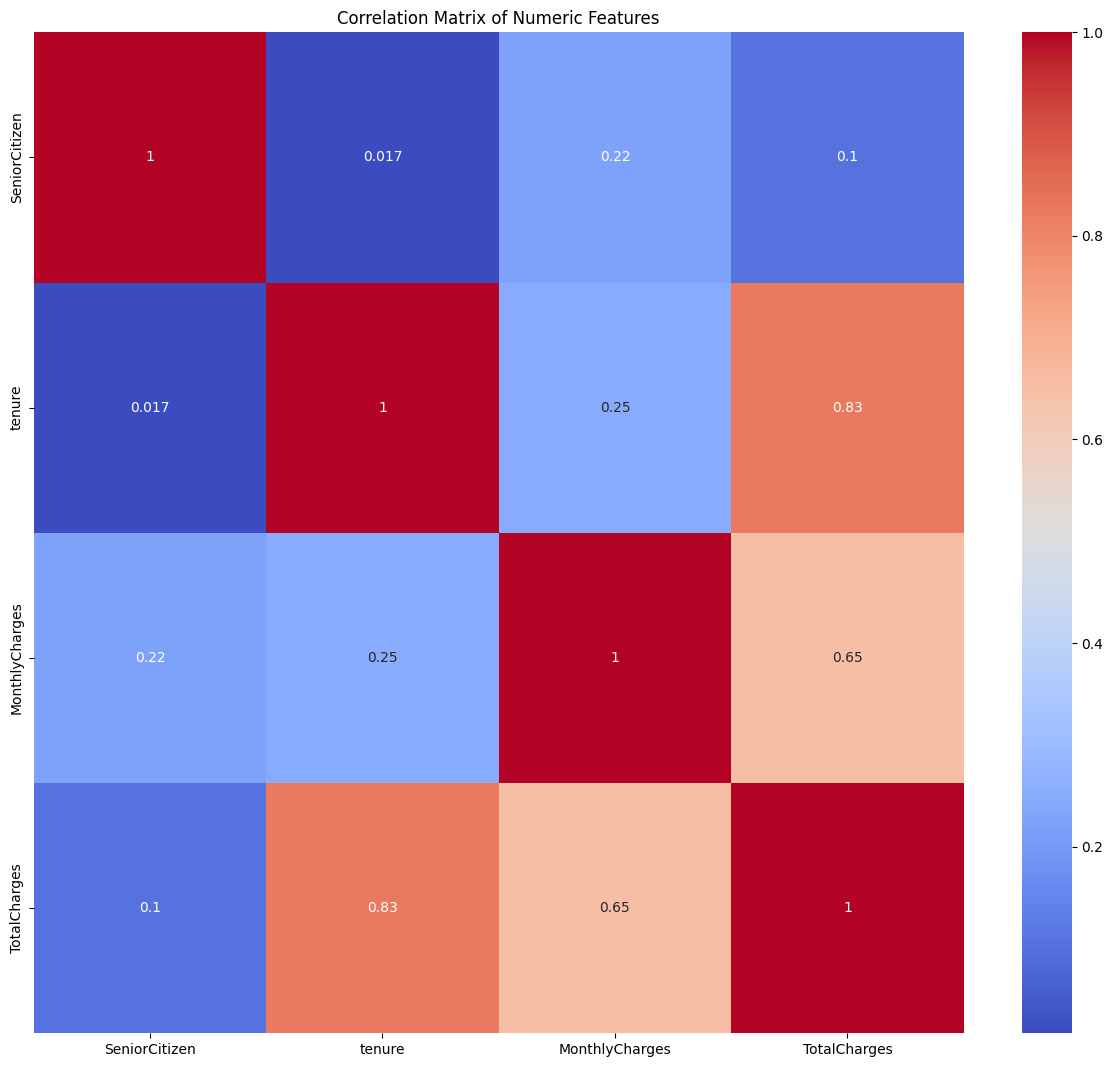

In [ ]:
correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(15, 13))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# **OUTLIER**

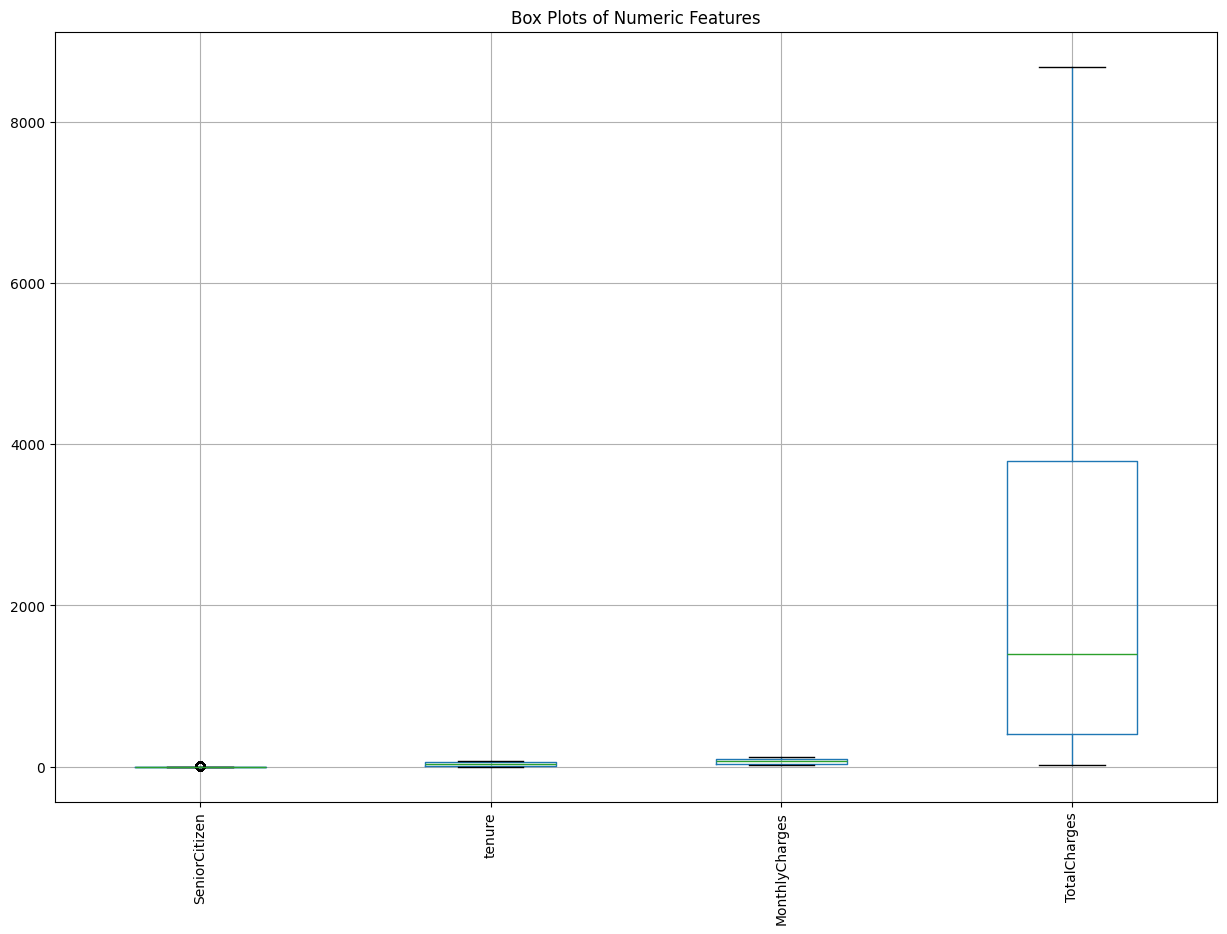

In [ ]:
plt.figure(figsize=(15, 10))
df[numeric_features].boxplot()
plt.title('Box Plots of Numeric Features')
plt.xticks(rotation=90)
plt.show()

# **RANGE DATA**

In [ ]:
print(df.dtypes)

numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    non_numeric = df[pd.to_numeric(df[col], errors='coerce').isna()]
    if len(non_numeric) > 0:
        print(f"\nNilai non-numerik dalam kolom {col}:")
        print(non_numeric[col].unique())

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Nilai non-numerik dalam kolom TotalCharges:
[nan]


In [ ]:
for col in numeric_columns:
    print(f"\nRange nilai untuk {col}:")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")

categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"\nKategori unik dalam {col}:")
    print(df[col].unique())


Range nilai untuk SeniorCitizen:
Min: 0, Max: 1

Range nilai untuk tenure:
Min: 0, Max: 72

Range nilai untuk MonthlyCharges:
Min: 18.25, Max: 118.75

Range nilai untuk TotalCharges:
Min: 18.8, Max: 8684.8

Kategori unik dalam gender:
['Female' 'Male']

Kategori unik dalam Partner:
['Yes' 'No']

Kategori unik dalam Dependents:
['No' 'Yes']

Kategori unik dalam PhoneService:
['No' 'Yes']

Kategori unik dalam MultipleLines:
['No phone service' 'No' 'Yes']

Kategori unik dalam InternetService:
['DSL' 'Fiber optic' 'No']

Kategori unik dalam OnlineSecurity:
['No' 'Yes' 'No internet service']

Kategori unik dalam OnlineBackup:
['Yes' 'No' 'No internet service']

Kategori unik dalam DeviceProtection:
['No' 'Yes' 'No internet service']

Kategori unik dalam TechSupport:
['No' 'Yes' 'No internet service']

Kategori unik dalam StreamingTV:
['No' 'Yes' 'No internet service']

Kategori unik dalam StreamingMovies:
['No' 'Yes' 'No internet service']

Kategori unik dalam Contract:
['Month-to-month' 

# **PREPROCESSING DATA**

# **Missing Values**

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)
missing_table = pd.concat([missing_values, missing_percentage], axis=1, keys=['Total', 'Percent'])

print(missing_table)

                  Total   Percent
gender                0  0.000000
SeniorCitizen         0  0.000000
Partner               0  0.000000
Dependents            0  0.000000
tenure                0  0.000000
PhoneService          0  0.000000
MultipleLines         0  0.000000
InternetService       0  0.000000
OnlineSecurity        0  0.000000
OnlineBackup          0  0.000000
DeviceProtection      0  0.000000
TechSupport           0  0.000000
StreamingTV           0  0.000000
StreamingMovies       0  0.000000
Contract              0  0.000000
PaperlessBilling      0  0.000000
PaymentMethod         0  0.000000
MonthlyCharges        0  0.000000
TotalCharges         11  0.156673
Churn                 0  0.000000


In [ ]:
df = df.dropna()

print(f"Jumlah Data Awal : {df.shape[0]}")
print(f"Jumlah Data Setelah Dihapus : {df.shape[0]}")

Jumlah Data Awal : 7010
Jumlah Data Setelah Dihapus : 7010


# **Duplicate Data**

In [ ]:
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")

if duplicates > 0:
    print("\nContoh baris duplikat:")
    print(df[df.duplicated(keep=False)].head(10))

Jumlah baris duplikat: 0


# **TRANSFORMASI DATA**

In [ ]:
for col in numeric_columns:
    print(f"\nRange nilai untuk {col}:")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")

categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"\nKategori unik dalam {col}:")
    print(df[col].unique())


Range nilai untuk SeniorCitizen:
Min: 0, Max: 1

Range nilai untuk tenure:
Min: 1, Max: 72

Range nilai untuk MonthlyCharges:
Min: 18.25, Max: 118.75

Range nilai untuk TotalCharges:
Min: 18.8, Max: 8684.8

Kategori unik dalam gender:
['Female' 'Male']

Kategori unik dalam Partner:
['Yes' 'No']

Kategori unik dalam Dependents:
['No' 'Yes']

Kategori unik dalam PhoneService:
['No' 'Yes']

Kategori unik dalam MultipleLines:
['No phone service' 'No' 'Yes']

Kategori unik dalam InternetService:
['DSL' 'Fiber optic' 'No']

Kategori unik dalam OnlineSecurity:
['No' 'Yes' 'No internet service']

Kategori unik dalam OnlineBackup:
['Yes' 'No' 'No internet service']

Kategori unik dalam DeviceProtection:
['No' 'Yes' 'No internet service']

Kategori unik dalam TechSupport:
['No' 'Yes' 'No internet service']

Kategori unik dalam StreamingTV:
['No' 'Yes' 'No internet service']

Kategori unik dalam StreamingMovies:
['No' 'Yes' 'No internet service']

Kategori unik dalam Contract:
['Month-to-month' 

In [ ]:
gender_map = {'Male': 1, 'Female': 0}
df['gender'] = df['gender'].map(gender_map)


no_internet_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in no_internet_cols:
    df[col] = df[col].replace('No internet service', 'No')

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')


binary_yes_no_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

binary_map = {'Yes': 1, 'No': 0}
for col in binary_yes_no_cols:
    df[col] = df[col].map(binary_map)


multi_categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']

for col in multi_categorical_cols:
    df[col] = df[col].astype('category')


df.head(5)

/tmp/ipykernel_642/2268170867.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender'] = df['gender'].map(gender_map)
/tmp/ipykernel_642/2268170867.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].replace('No internet service', 'No')
/tmp/ipykernel_642/2268170867.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.or

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


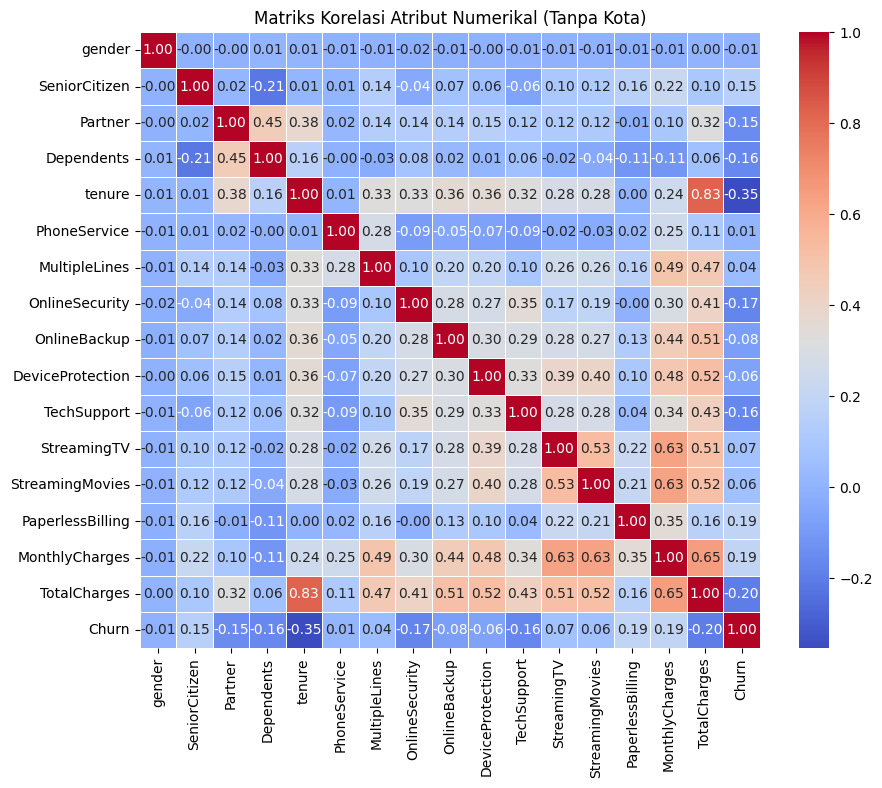

In [ ]:
df_numeric = df.select_dtypes(include=['number'])

corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Matriks Korelasi Atribut Numerikal (Tanpa Kota)')
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

fitur_cols = df.drop(columns=['Churn']).columns
n_features = len(fitur_cols)

corr_matrix = pd.DataFrame(np.zeros((n_features, n_features)), columns=fitur_cols, index=fitur_cols)

for i in range(n_features):
    for j in range(n_features):
        col1 = fitur_cols[i]
        col2 = fitur_cols[j]

        if df[col1].dtype in ['int64', 'float64'] and df[col2].dtype in ['int64', 'float64']:
            corr_matrix.iloc[i, j] = abs(df[col1].corr(df[col2]))
        else:
            corr_matrix.iloc[i, j] = cramers_v(df[col1], df[col2])

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]

print(f"Fitur kategori/numerik yang redundancy tinggi (>0.80): {to_drop}")

df_filtered = df.drop(columns=to_drop)

Fitur kategori/numerik yang redundancy tinggi (>0.80): ['TotalCharges']


# **MODELLING**

# **Modelling**

In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

X = df_filtered.drop(columns=['Churn'])
y = df_filtered['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = xgb.XGBClassifier(enable_categorical=True, scale_pos_weight=2.7)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 5608 samples
Testing set size: 1402 samples


# **XGBOOST**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, f1_score

format_target = y_train.value_counts()
sum_negative = format_target[0]
sum_positive = format_target[1]
scale_weight_value = sum_negative / sum_positive

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.9]
}

xg = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_weight_value,
    enable_categorical=True,
    tree_method='hist'
)



cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid_xgb,
    cv=cv_stratified,
    n_jobs=-1,
    scoring='f1',
    verbose=2
)

print("Memulai GridSearchCV untuk XGBoost...")
xgb_search.fit(X_train, y_train)
print("GridSearchCV selesai.")

print("\nParameter terbaik untuk XGBoost:")
print(xgb_search.best_params_)

best_model_xgb = xgb_search.best_estimator_

Memulai GridSearchCV untuk XGBoost...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
GridSearchCV selesai.

Parameter terbaik untuk XGBoost:
{'colsample_bytree': 0.7, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}



5. Evaluation (XGBoost)...
----------------------------------------
Accuracy (XGBoost)  : 0.7546
Precision (Macro)     : 0.7115
Recall (Macro)        : 0.7573
F1-Score (Macro)      : 0.7202
ROC-AUC Score         : 0.8390
----------------------------------------

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1031
           1       0.53      0.76      0.62       371

    accuracy                           0.75      1402
   macro avg       0.71      0.76      0.72      1402
weighted avg       0.80      0.75      0.77      1402

Confusion Matrix (XGBoost):
[[775 256]
 [ 88 283]]


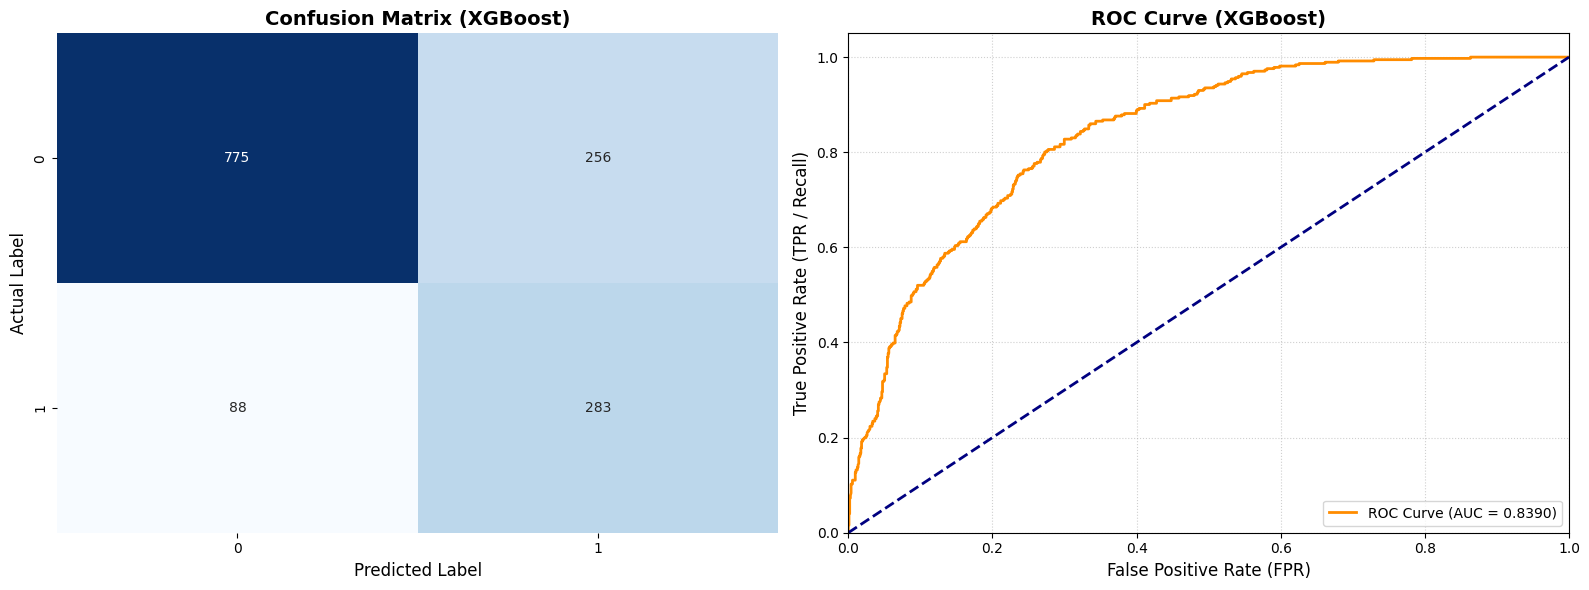

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)

print("\n5. Evaluation (XGBoost)...")

y_pred_xgb = best_model_xgb.predict(X_test)
y_pred_proba_xgb = best_model_xgb.predict_proba(X_test)[:, 1]

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='macro')
recall_xgb = recall_score(y_test, y_pred_xgb, average='macro')
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("-" * 40)
print(f"Accuracy (XGBoost)  : {accuracy_xgb:.4f}")
print(f"Precision (Macro)     : {precision_xgb:.4f}")
print(f"Recall (Macro)        : {recall_xgb:.4f}")
print(f"F1-Score (Macro)      : {f1_xgb:.4f}")
print(f"ROC-AUC Score         : {roc_auc_xgb:.4f}")
print("-" * 40)

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix (XGBoost):")
print(cm_xgb)

class_labels = [str(cls) for cls in sorted(list(set(y_test)))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm_xgb, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_labels, yticklabels=class_labels,
    ax=axes[0], cbar=False
)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_title('Confusion Matrix (XGBoost)', fontsize=14, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_xgb:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
axes[1].set_title('ROC Curve (XGBoost)', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` instead. 
  warnings.warn(


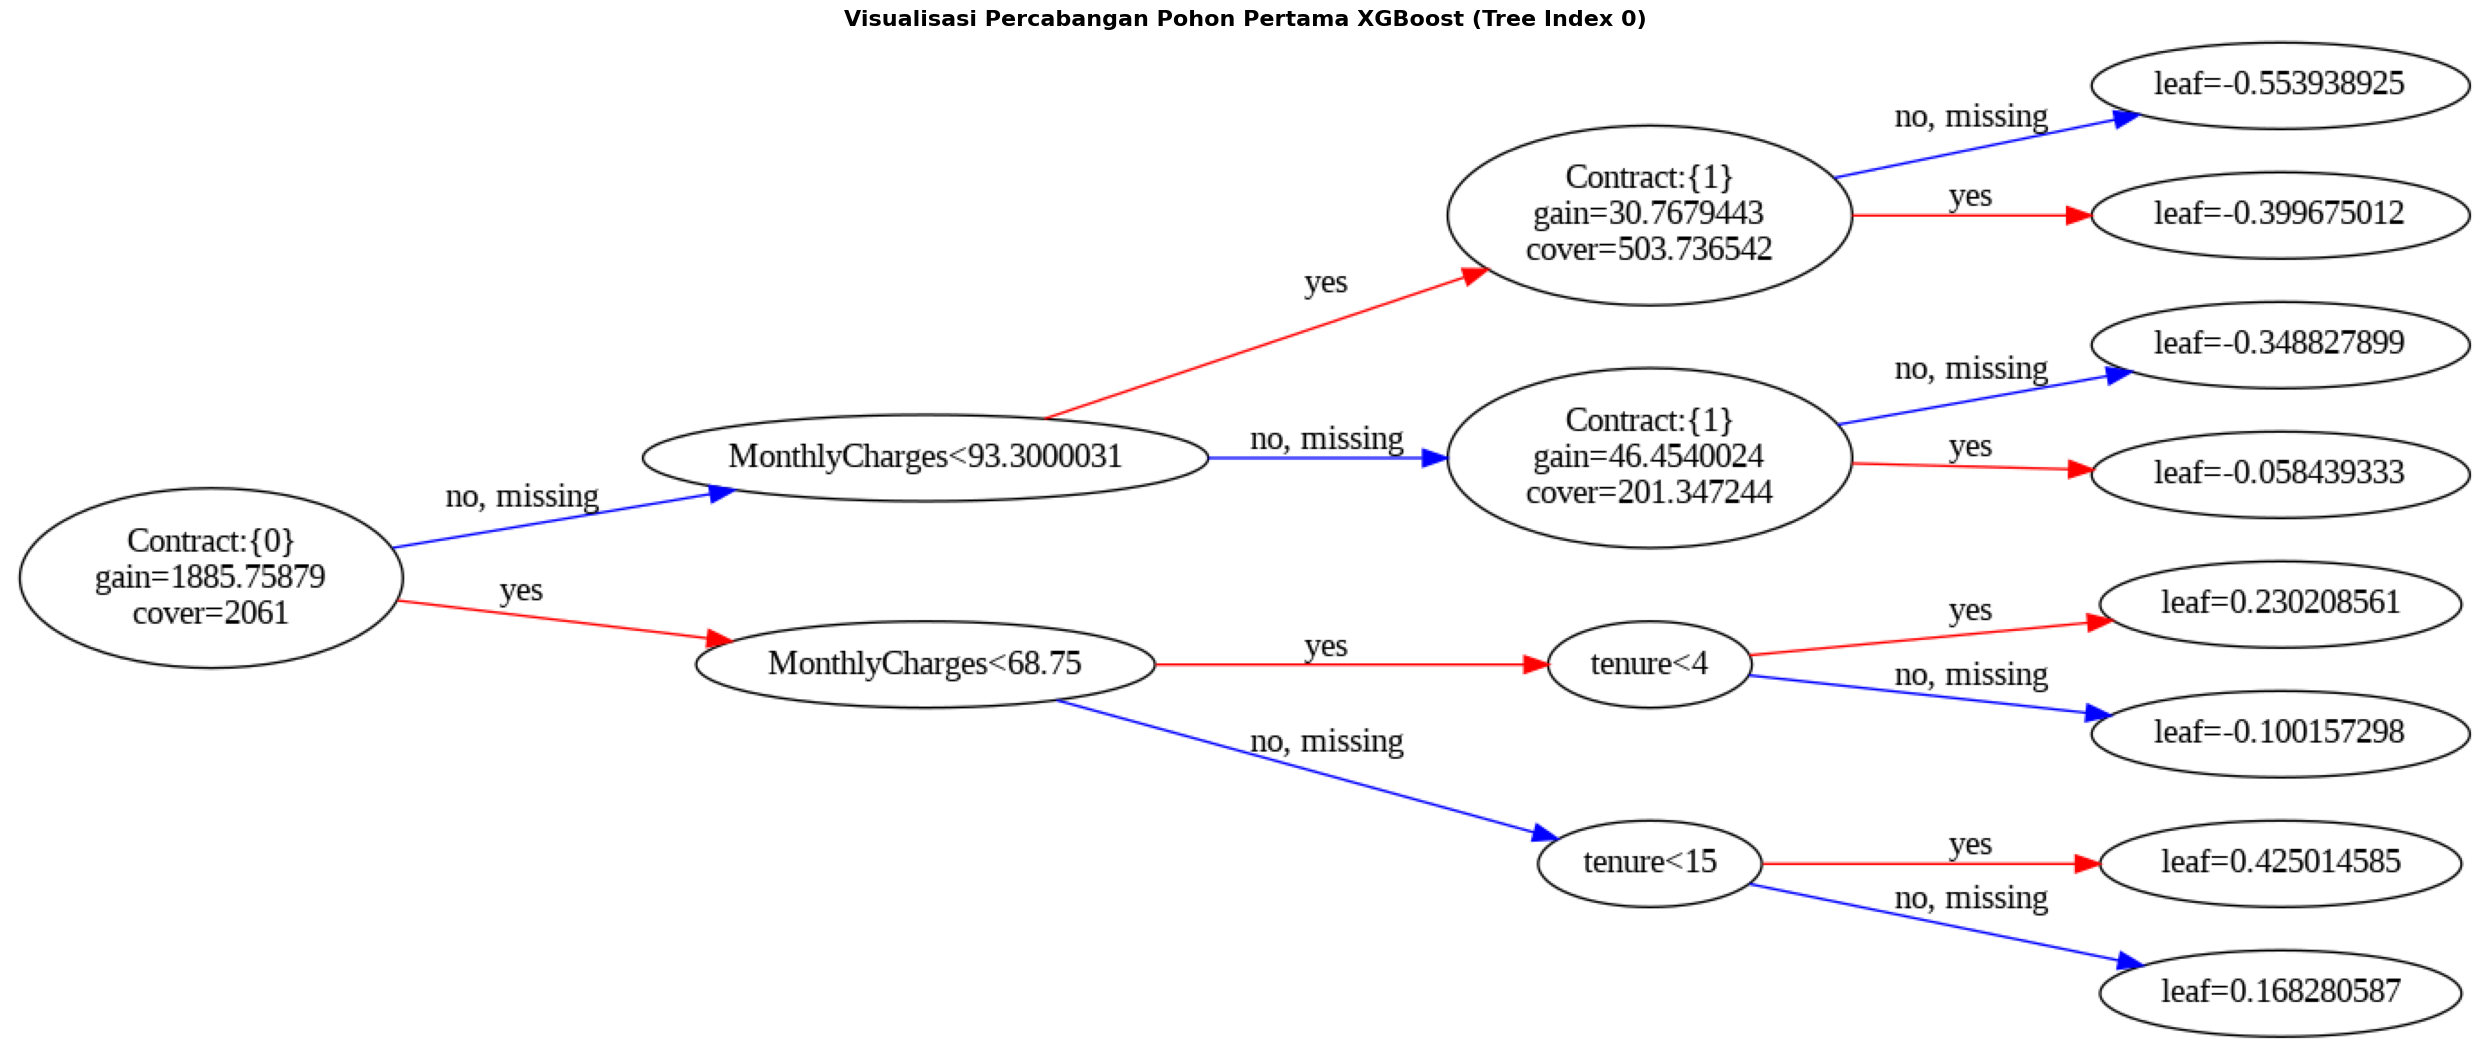

In [ ]:
fig, ax = plt.subplots(figsize=(25, 15))

xgb.plot_tree(best_model_xgb, num_trees=0, ax=ax, rankdir='LR')

plt.title('Visualisasi Percabangan Pohon Pertama XGBoost (Tree Index 0)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_642/4286835068.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


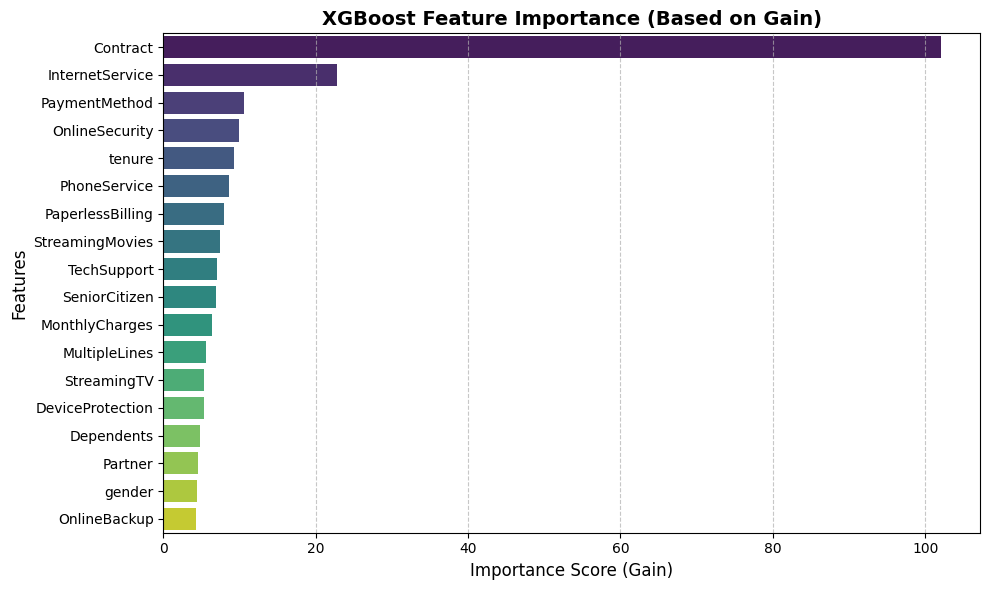

In [ ]:
importance_scores = best_model_xgb.get_booster().get_score(importance_type='gain')

feature_imp_df = pd.DataFrame({
    'Feature': list(importance_scores.keys()),
    'Importance': list(importance_scores.values())
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')

plt.title('XGBoost Feature Importance (Based on Gain)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()